<a href="https://colab.research.google.com/github/Alianaggrey/lab-3-nn-framework/blob/main/lab_3_advanced_nn_framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3 (Advanced Track): Building a Neural Network Framework from Scratch

**Duration:** 1 week [02 Jul - 09 Jul, 2026]
**Due Date:** 9th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab (advanced/elective track).

**Student Name:** [Isaac Alvin Nhyira Aggrey]
**Student ID:** [70052026]

---

### Objective

The standard track builds one small network by hand. You will build a **miniature deep
learning framework** — a modular, reusable library in pure NumPy with the same architecture
as PyTorch itself: composable layers, each implementing `forward()` and `backward()`,
pluggable optimizers, and a proper multi-class loss.

You will then **prove your framework is correct** with numerical gradient checking, implement
and race **three optimizers** (SGD, Momentum, Adam), investigate **weight initialization**,
and finally train the same architecture in PyTorch on the Lab 2 obesity dataset — verifying
that your scratch framework and PyTorch agree.

If you finish everything, a bonus challenge awaits: implementing Batch Normalization,
forward **and** backward.

**Rules of the advanced track:**
- Pure NumPy in Sections 1-3. No autograd, no PyTorch, no copying gradient formulas you
  cannot derive.
- Every derivation asked for must appear in the notebook (LaTeX in a markdown cell, or a
  clear photo of handwritten work).

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3-nn-framework`.
2. Save this notebook inside it, plus a `requirements.txt`: `numpy pandas matplotlib scikit-learn torch`.
3. Commit and push after completing **each Part** — we will check for incremental commits.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# PyTorch is only allowed from Section 4 onward.

---
# Section 1 — A Modular Layer API

Every deep learning framework is built on one abstraction: a **layer** that knows how to push
activations forward and gradients backward. You will implement this API:

```python
class Layer:
    def forward(self, x):            # returns output, caches what backward needs
        raise NotImplementedError
    def backward(self, grad_out):    # returns grad wrt input; stores grads wrt params
        raise NotImplementedError
    @property
    def params_and_grads(self):      # yields (param, grad) pairs for the optimizer
        return []
```


### Part 1.1 — The Dense (fully-connected) layer
Forward: `Y = X W + b`. Derive and implement the three backward gradients.

In [3]:
# TODO: Derive on paper (and include in the next markdown cell) for Y = XW + b with
#   incoming gradient dY = dL/dY:
#     dL/dW = X^T dY
#     dL/db = sum over batch of dY
#     dL/dX = dY W^T
#   Pay attention to shapes: X is (B, n_in), W is (n_in, n_out).

class Dense:
    def __init__(self, n_in, n_out, init="he"):
        # TODO: initialise self.W, self.b
        if init == "naive":
          self.W = np.random.randn(n_in, n_out)* 0.01
        elif init == "he":
          self.W = np.random.randn(n_in, n_out) * np.sqrt(2.0 / n_in)
        # TODO: create self.dW, self.db placeholders
        self.b = np.zeros(n_out)
        self.dW = None
        self.db = None


    def forward(self, x):
        # TODO: cache x for the backward pass; return x @ W + b
        self.x = x
        return x @ self.W + self.b


    def backward(self, grad_out):
        # TODO: compute self.dW, self.db; return grad wrt input
        self.dW = self.x.T @ grad_out
        self.db = np.sum(grad_out, axis=0)
        return grad_out @ self.W.T
        pass

    @property
    def params_and_grads(self):
        return [(self.W, self.dW), (self.b, self.db)]

**Derivation — Dense backward** *(replace this with your derivation)*

> [LaTeX or photo here]

### Part 1.2 — Activations and the loss
Implement ReLU, and the fused **Softmax + Cross-Entropy** loss with its famously clean gradient.

In [4]:
class ReLU:
    def forward(self, x):
        # TODO: cache the mask (x > 0); return np.maximum(0, x)
        self.mask = x>0
        return np.maximum(0, x)
    def backward(self, grad_out):
        # TODO: return grad_out * mask
        return grad_out * self.mask
    @property
    def params_and_grads(self):
        return []


class SoftmaxCrossEntropy:
    """Combines softmax and cross-entropy for numerical stability.
    forward(logits, y) -> scalar mean loss   (y: integer class labels, shape (B,))
    backward()         -> dL/dlogits, shape (B, C)
    """
    def forward(self, logits, y):
        # TODO:
        #  - subtract the row-wise max from logits BEFORE exponentiating (why? -> reasoning box)
        logit_shift = logits - np.max(logits, axis=1, keepdims=True)
        #  - probs = softmax(shifted logits); cache probs and y
        exp_logits = np.exp(logit_shift)
        probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
        self.probs = probs
        self.y = y
        #  - return mean of -log(probs[range(B), y])
        B = logits.shape[0]
        loss = -np.log(probs[np.arange(B), y]).mean()

        return loss

    def backward(self):
        # TODO: derive first, then implement:  (probs - one_hot(y)) / B
        grad = self.probs.copy()
        grad[np.arange(self.probs.shape[0]), self.y] -= 1
        B = self.probs.shape[0]
        return grad/B


**Derivation — Softmax + CE gradient** *(replace this with your derivation)*

Show that for `L = -log softmax(z)_y`, the gradient is `dL/dz = p - onehot(y)`.

> [LaTeX or photo here]

**Student Reasoning — The layer API**
*1. Why must each layer cache values from `forward` to use in `backward`? What exactly does
each of your layers cache, and what is the memory cost?*

ANSWER: Each layer needs values form the forward pass to calculate its gradients during the backward pass hence they cache these values.

Linear layer: Caches input.
ReLU: Caches input showing which values were positive
Softmax: Caches output probabilities

*2. Why do we subtract the row-max before exponentiating in softmax? Show a concrete input
that overflows without it.*
For z = [1000, 999, 998] for example, trying to calculate e^1000 will overflow in normal floating-point arithmetic. Hence why we subtract the largest value from each element.

ANSWER:
*3. Why do frameworks fuse softmax and cross-entropy into one op instead of chaining their
separate gradients?*

Because calculating their gradients spearately is less numerically stable. The fused operation can calculate the loss and gradient more efficiently.



### Part 1.3 — The network container and gradient checking
Chain layers into a `Sequential`, then **prove your gradients are right** — the way real
framework developers do — by comparing against numerical differentiation.

In [5]:
class Sequential:
    def __init__(self, layers):
        self.layers = layers
    def forward(self, x):
        # TODO: fold x through all layers
        for layer in self.layers:
          x = layer.forward(x)
        return x
    def backward(self, grad):
        # TODO: fold grad through all layers in REVERSE
        for layer in reversed(self.layers):
          grad = layer.backward(grad)
        return grad
    @property
    def params_and_grads(self):
        return [pg for layer in self.layers for pg in layer.params_and_grads]


def numerical_gradient(f, param, eps=1e-5):
    """Central differences: for each entry p_i, (f(p_i+eps) - f(p_i-eps)) / (2 eps)."""
    # TODO: implement with np.nditer or plain loops (slow is fine — this is a test, not prod)
    grad = np.zeros_like(param)
    iterator = np.nditer(param, flags=["multi_index"])
    while not iterator.finished:
      index = iterator.multi_index
      original = param[index]
      #f(p+eps)
      param[index] = original + eps
      f_plus = f()

      #f(p-eps)
      param[index] = original - eps
      f_minus = f()

      # Restore original parameter value
      param[index] = original

      # Central difference
      grad[index] = (f_plus - f_minus) / (2 * eps)

      print(index, param[index])
      iterator.iternext()
    return grad

# TODO: Gradient check
#   - Build a tiny model: Dense(5, 4) -> ReLU -> Dense(4, 3), batch of 6 random samples
#   - Compute analytic grads via your backward pass
#   - Compute numerical grads of the loss wrt EVERY parameter tensor
#   - Report max relative error:  |a - n| / max(|a|, |n|, 1e-8)
#   - PASS if < 1e-5. If it fails, your backward has a bug — fix it before continuing!

model = Sequential([Dense(5, 4), ReLU(), Dense(4, 3)])
X = np.random.randn(6, 5)
y = np.random.randint(0, 3, size=6)

loss_function = SoftmaxCrossEntropy()

logits = model.forward(X)
loss = loss_function.forward(logits, y)

grad_logits = loss_function.backward()
model.backward(grad_logits)

analytic_grads = [grad for _, grad in model.params_and_grads]

numerical_grads = []
for param, _ in model.params_and_grads:
  def f():
    logits = model.forward(X)
    return loss_function.forward(logits, y)

  numerical_grads.append(numerical_gradient(f, param))

max_relative_error = 0.0
for (param, analytic), numerical in zip(model.params_and_grads, numerical_grads):
  relative_error = np.abs(analytic - numerical)/ np.maximum(np.maximum(np.abs(analytic), np.abs(numerical)),1e-8)
  max_error = np.max(relative_error)
  max_relative_error = max(max_relative_error, max_error)

print(max_relative_error)
if max_relative_error < 1e-5:
  print("PASS")
else:
  print("FAIL")



(0, 0) 0.31414961391137586
(0, 1) -0.08744602215848599
(0, 2) 0.4096341989565872
(0, 3) 0.9632486581377107
(1, 0) -0.14809159718812812
(1, 1) -0.14808121367603985
(1, 2) 0.9987818814261264
(1, 3) 0.4853683399275229
(2, 0) -0.29692167253267343
(2, 1) 0.34314510102637563
(2, 2) -0.2930910834615244
(2, 3) -0.2945533590781896
(3, 0) 0.15303037719537288
(3, 1) -1.2100646750645692
(3, 2) -1.0909338254764052
(3, 3) -0.35562185846200045
(4, 0) -0.640570645071372
(4, 1) 0.19874746392670745
(4, 2) -0.5742848497831541
(4, 3) -0.8932192888211414
(0,) 0.0
(1,) 0.0
(2,) 0.0
(3,) 0.0
(0, 0) 1.0363701833421461
(0, 1) -0.159647953105241
(0, 2) 0.04774965145618416
(1, 0) -1.0074491039547693
(1, 1) -0.38493671607256497
(1, 2) 0.07843411537061946
(2, 0) -0.8138753636974738
(2, 1) 0.2656586164505726
(2, 2) -0.42471569068459103
(3, 0) -0.2062586285085581
(3, 1) -0.425470825792191
(3, 2) 1.309758464910177
(0,) 0.0
(1,) 0.0
(2,) 0.0
3.8650754045132184e-09
PASS


**Student Reasoning — Gradient checking**
*1. Report your max relative error per parameter tensor. What bug (if any) did the check
catch?*

ANSWER:
Max relative error = 3.8650754045132184e-09

*2. Why central differences rather than the one-sided `(f(p+eps) - f(p)) / eps`?*

ANSWER: Central differences are more accurate because they use information from bothe sides of the parameter instead of only looking at f(p+eps). This reduces approximation error and gives a better estimate of the true gradient.

*3. Why don't we just USE numerical gradients for training and skip backprop entirely?
Estimate the number of forward passes per update for your Section 4 network.*

ANSWER: It has greater computation costs than backpropagation.

---
# Section 2 — Optimizers: SGD, Momentum, Adam — from scratch

The optimizer is just a rule for turning gradients into updates. Implement three, then race
them on a problem where the differences are visible.

In [6]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr
    def step(self, params_and_grads):
        # TODO: p -= lr * g   (in-place: p[...] -= ...)
        for p, g in params_and_grads:
          p[...] -= self.lr * g



class Momentum:
    def __init__(self, lr=0.01, beta=0.9):
        # TODO: keep one velocity buffer per parameter (dict keyed by id(param))
        self.lr = lr
        self.beta = beta

        self.velocity = {}
    def step(self, params_and_grads):
        # TODO: v = beta * v + g ;  p -= lr * v
        for p, g in params_and_grads:
          key = id(p)
          if key not in self.velocity:
            self.velocity[key] = np.zeros_like(p)

          v = self.velocity[key]

          v[...] = self.beta * v + g

          p[...] -= self.lr



class Adam:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        # TODO: first & second moment buffers per parameter + timestep t
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

        self.m = {}
        self.v = {}
        self.t = 0
    def step(self, params_and_grads):
        # TODO: full Adam with bias correction:
        #   m = b1*m + (1-b1)*g ;  v = b2*v + (1-b2)*g^2
        #   m_hat = m / (1 - b1^t) ;  v_hat = v / (1 - b2^t)
        #   p -= lr * m_hat / (sqrt(v_hat) + eps)
        self.t += 1

        for p, g in params_and_grads:
          key = id(p)

          if key not in self.m:
            self.m[key] = np.zeros_like(p)
            self.v[key] = np.zeros_like(p)

          m = self.m[key]
          v = self.v[key]

          m[...] = self.beta1 * m + (1 - self.beta1) * g
          v[...] = self.beta2 * v + (1 - self.beta2) * (g**2)

          m_hat = m/(1 - self.beta1 ** self.t)
          v_hat = v/(1 - self.beta2 ** self.t)

          p[...] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


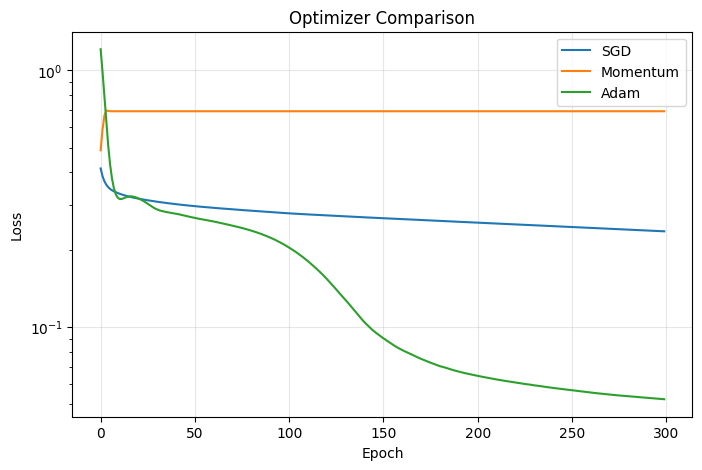

In [7]:
# The racetrack: two moons — a classic non-linearly-separable 2D dataset.
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=400, noise=0.20, random_state=RANDOM_STATE)

# TODO: Write a train(model_fn, optimizer, epochs=300) loop using full-batch training:
#   forward -> loss -> backward -> optimizer.step(model.params_and_grads)
#   model_fn should REBUILD the model with the same seed each time (fair race!)
#   Architecture: Dense(2, 32) -> ReLU -> Dense(32, 32) -> ReLU -> Dense(32, 2)
def model():
  return Sequential([Dense(2, 32), ReLU(), Dense(32, 32), ReLU(), Dense(32, 2)])

def train(model_fn, optimizer, epochs=300):
  model = model_fn()
  loss_function = SoftmaxCrossEntropy()

  losses = []

  for epoch in range(epochs):
    logits = model.forward(X_moons)

    # loss
    loss = loss_function.forward(logits, y_moons)
    losses.append(float(loss))

    # backward
    grad_logits = loss_function.backward()
    model.backward(grad_logits)

    optimizer.step(model.params_and_grads)

  return model, np.array(losses)

# TODO: Race SGD(lr=0.05), Momentum(lr=0.05), Adam(lr=0.005) — plot the three loss curves
#   on the same axes (log y-scale).
def sgd_model():
  return model()

def momentum_model():
  return model()

def adam_model():
  return model()

# Train each optimizer
sgd_model, sgd_losses = train(
    model,
    SGD(lr=0.05),
    epochs=300
)

momentum_model, momentum_losses = train(
    model,
    Momentum(lr=0.05),
    epochs=300
)

adam_model, adam_losses = train(
    model,
    Adam(lr=0.005),
    epochs=300
)


plt.figure(figsize=(8, 5))

plt.plot(sgd_losses, label="SGD")
plt.plot(momentum_losses, label="Momentum")
plt.plot(adam_losses, label="Adam")

plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimizer Comparison")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


# TODO: Plot the decision boundary of the best model over the scattered data
#   (meshgrid -> predict -> contourf).

**Student Reasoning — Optimizers**
*1. Which optimizer won, and was the ranking what theory predicts? Quote final losses.*

The Adam optimizer won. It finishes at the lowest loss at epoch 300. Adam in theory should beat SGD but Momentum should beat Adam. The deviation is probably due to a high learning rate.
*2. Explain bias correction in Adam: what goes wrong in the first ~10 steps without it?*
Bias correction rescales Adam's moment which exactly cancels out the fact that both moving averages start at zero and are therefore artificially small in the first few steps.
*3. Momentum uses a velocity buffer. Give the physics analogy AND state precisely what
problem it solves that plain SGD has (think: ravines / oscillation).*

Momentum can be thought of as giving a ball velocity as it moves down a loss surface. The main problem it helps solve is when the model keeps moving back and forth instead of moving steadily toward the minimum.

> **Answer:** [Double-click to edit]

### Part 2.2 — Weight initialization: why scale matters
Naive initialization silently kills deep networks. Demonstrate it.

Naive activation stds:
[np.float64(0.01198047882924001), np.float64(0.007339904093330788), np.float64(0.0006443271759922812), np.float64(0.00037609618904673646), np.float64(4.247581928164118e-05), np.float64(2.617227702641201e-05), np.float64(2.711888240334776e-06), np.float64(1.7690656233510302e-06), np.float64(1.5127242464716494e-07), np.float64(8.262542879988077e-08), np.float64(8.795514010254418e-09), np.float64(5.161990767550072e-09)]

He activation stds:
[np.float64(1.284462983065591), np.float64(0.6953752817959719), np.float64(1.235283202647097), np.float64(0.777204500054449), np.float64(1.4384850943343155), np.float64(0.8301624390239886), np.float64(1.4408804430592275), np.float64(0.8891817905537068), np.float64(1.272640453156848), np.float64(0.5690383771727822), np.float64(1.0195900719844297), np.float64(0.6333633759708058)]


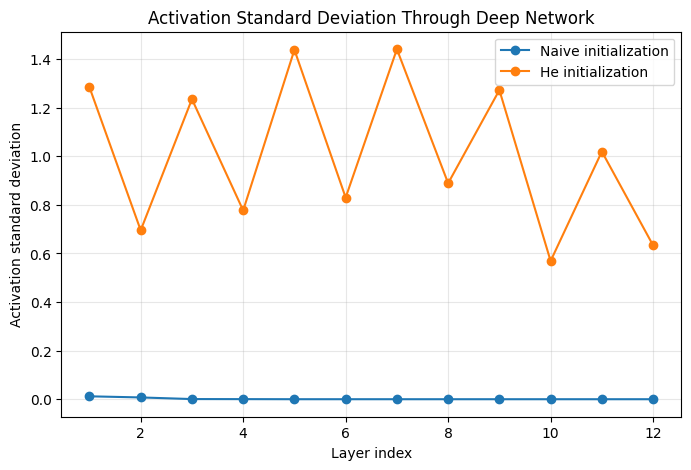

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 16)

In [16]:
# TODO: Build a DEEP network: 6 Dense layers of width 64, ReLU between each,
#   once with init="naive" (std 0.01) and once with init="he".
def deep_model(init_type):
  layers = []
  layers.append(Dense(2, 64, init=init_type))
  layers.append(ReLU())
  for _ in range(5):
    layers.append(Dense(64, 64, init=init_type))
    layers.append(ReLU())

  return Sequential(layers)

naive_model = deep_model("naive")
he_model = deep_model("he")
# TODO: Push one batch of moons data through each UNTRAINED network and record the
#   standard deviation of activations after every layer. Plot std vs layer index for both.
X_batch = X_moons[:64]
def std_activations(model, X):
  activations = []
  current = X

  for layer in model.layers:
    current = layer.forward(current)
    activations.append(np.std(current))
  return activations

naive_stds = std_activations(naive_model, X_batch)
he_stds = std_activations(he_model, X_batch)

print("Naive activation stds:")
print(naive_stds)

print("\nHe activation stds:")
print(he_stds)
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(naive_stds) + 1),
    naive_stds,
    marker="o",
    label="Naive initialization"
)

plt.plot(
    range(1, len(he_stds) + 1),
    he_stds,
    marker="o",
    label="He initialization"
)

plt.xlabel("Layer index")
plt.ylabel("Activation standard deviation")
plt.title("Activation Standard Deviation Through Deep Network")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
# TODO: Train both for 300 epochs with Adam; plot the two loss curves.

naive_model, naive_history = minibatch(
    lambda: deep_model("naive"), Adam(lr=0.001), epochs=300,batch_size=32
)

he_model, he_history = minibatch(
    lambda: deep_model("he"), Adam(lr=0.001), epochs=300, batch_size=32
)


# Plot the two loss curves

plt.figure(figsize=(8, 5))

plt.plot(
    naive_history["loss"],
    label="Naive initialization",
    linewidth=2
)

plt.plot(
    he_history["loss"],
    label="He initialization",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Training Loss: Naive vs He Initialization")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()



In [17]:
print(X_moons.shape)
print(X_train.shape)


(400, 2)
(1266, 16)


**Student Reasoning — Initialization**
*1. Describe the activation-std plot: what happens to the signal in the naive network by
layer 6? What does that do to the gradients flowing back?*

ANSWER: The naive network's activations shrink extremely quickly. By layer 6, the standard deviation is already around 2.6*10^-5 compared with about 0.83 for He initialization. By the final layers, the naive activations are effectively zero.

During backpropagation, the same problem affects the gradients: very small activations and derivatives cause the gradients to become extremely small as they pass backward through the layers.


*2. Derive (or clearly argue) why He initialization uses sqrt(2/n_in) — where does the
factor 2 come from for ReLU specifically?*

ANSWER: The goal is to keep the variance of the activations roughly constant as they pass through each layer.



---
# Section 3 — Your Framework vs a Real Problem

Now point your framework at the **Lab 2 obesity dataset** (7 classes, tabular) — the same
data the standard track uses, but running on YOUR code.

Loaded: 2111 rows x 17 columns
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2

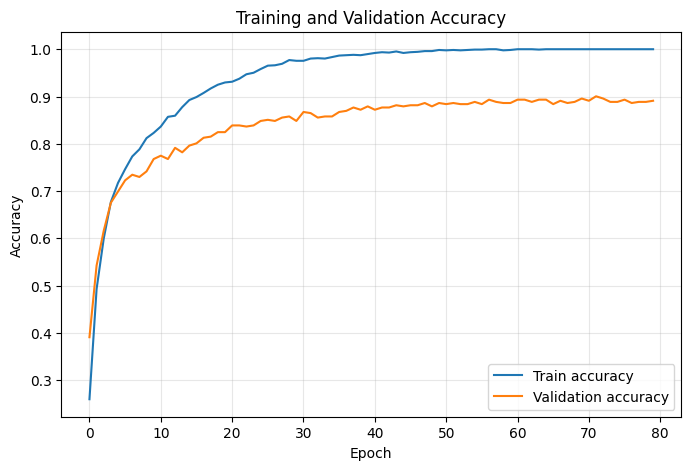

Best validation accuracy: 0.9005
Best epoch: 72


In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

def accuracy(logits, y):
    predictions = np.argmax(logits, axis=1)
    return np.mean(predictions == y)

# TODO: Load and preprocess the obesity dataset exactly as in Lab 2:
# Dataset URLs (already provided for you)
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

# Load the obesity dataset
obesity = pd.read_csv(OBESITY_URL)

obesity.columns = obesity.columns.str.strip()

print(f"Loaded: {obesity.shape[0]} rows x {obesity.shape[1]} columns")
print(obesity.head())


#   encode categoricals, integer-encode NObeyesdad (0..6), stratified 60/20/20 split,
# Separate features and target
X_df = obesity.drop(columns=["NObeyesdad"]).copy()
y = obesity["NObeyesdad"].copy()

categorical_cols = X_df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    X_df[col] = LabelEncoder().fit_transform(X_df[col])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)


X = X_df.to_numpy(dtype=np.float64)
y = np.asarray(y, dtype=np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", label_encoder.classes_)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=y
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


#   StandardScaler fitted on train only.
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Train mean:", np.mean(X_train, axis=0))
print("Train std:", np.std(X_train, axis=0))


# TODO: Implement mini-batch training for your framework (shuffle indices each epoch,
#   slice into batches of 32).
def minibatch(model_fn, optimizer, epochs=80, batch_size=32):
    model = model_fn()
    loss_function = SoftmaxCrossEntropy()

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    n = X_train.shape[0]

    for epoch in range(epochs):

        # Shuffle training data
        indices = np.random.permutation(n)

        epoch_loss = 0.0
        epoch_correct = 0
        epoch_samples = 0

        # Mini-batches
        for start in range(0, n, batch_size):
            batch_indices = indices[start:start + batch_size]

            X_batch = X_train[batch_indices]
            y_batch = y_train[batch_indices]

            # Forward
            logits = model.forward(X_batch)

            # Loss
            loss = loss_function.forward(logits, y_batch)

            # Backward
            grad_logits = loss_function.backward()
            model.backward(grad_logits)

            # Update
            optimizer.step(model.params_and_grads)

            # Track batch statistics
            batch_size_actual = len(batch_indices)
            epoch_loss += loss * batch_size_actual
            epoch_correct += np.sum(
                np.argmax(logits, axis=1) == y_batch
            )
            epoch_samples += batch_size_actual

        # Average training statistics
        train_loss = epoch_loss / epoch_samples
        train_acc = epoch_correct / epoch_samples

        # Validation
        val_logits = model.forward(X_val)
        val_loss = loss_function.forward(val_logits, y_val)
        val_acc = accuracy(val_logits, y_val)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch + 1:3d}/{epochs} | "
                f"Train loss: {train_loss:.4f} | "
                f"Train acc: {train_acc:.4f} | "
                f"Val loss: {val_loss:.4f} | "
                f"Val acc: {val_acc:.4f}"
            )

    history = {
        "train_loss": np.array(train_losses),
        "val_loss": np.array(val_losses),
        "train_acc": np.array(train_accuracies),
        "val_acc": np.array(val_accuracies)
    }

    return model, history


# TODO: Train Dense(n_features, 64) -> ReLU -> Dense(64, 32) -> ReLU -> Dense(32, 7)
n_features = X_train.shape[1]

def obesity_model():
    return Sequential([
        Dense(n_features, 64, init="he"),
        ReLU(),
        Dense(64, 32, init="he"),
        ReLU(),
        Dense(32, 7, init="he")
    ])

#   with your Adam for ~80 epochs. Track train AND validation loss/accuracy per epoch.
obesity_model_trained, history = minibatch(
    obesity_model,
    Adam(lr=0.001),
    epochs=80,
    batch_size=32
)

# TODO: Plot the curves; report best validation accuracy.
plt.figure(figsize=(8, 5))

plt.plot(history["train_acc"], label="Train accuracy")
plt.plot(history["val_acc"], label="Validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

best_epoch = np.argmax(history["val_acc"]) + 1
best_val_accuracy = np.max(history["val_acc"])

print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print(f"Best epoch: {best_epoch}")


**Student Reasoning — Real data**
*1. Compare training on moons (full-batch) vs obesity (mini-batch): why do we switch to
mini-batches, and what changed in the loss curve's texture?*
ANSWER: For the moons dataset full-batch training works because the dataset is small so the model can use the entire dataset for each update. The same cannot be said for the obesity dataset which is larger hence the need to use mini-batch to reduce the amount of computation and memory.
The loss curve therefore becomes noisier or more frequent zig-zags as compared with the full-batch curve.


*2. Is your model overfitting? Quote numbers. Your framework has no dropout — name two
regularization levers you DO have available and try one.*

Yes it is. By epoch 70 training accuracy hits 10000 with train loss moving down to 0.0134 by epoch 80. Val loss on the other hand is at 0.4514 at epoch 60 and 0.4665 by epoch 80 showing the overfitting split.

- Early stopping
- L2 weight decay



---
# Section 4 — Parity Check: Your Framework vs PyTorch

The payoff. Build the **identical architecture in PyTorch**, train it on the same data, and
verify that your hand-built framework and a billion-dollar library agree.

Sequential(
  (0): Linear(in_features=16, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=7, bias=True)
)
Epoch  10/80 | Train loss: 0.4630 | Train acc: 0.8562 | Val loss: 0.6507 | Val acc: 0.7986
Epoch  20/80 | Train loss: 0.2154 | Train acc: 0.9376 | Val loss: 0.5086 | Val acc: 0.8365
Epoch  30/80 | Train loss: 0.1152 | Train acc: 0.9787 | Val loss: 0.4556 | Val acc: 0.8791
Epoch  40/80 | Train loss: 0.0640 | Train acc: 0.9937 | Val loss: 0.4450 | Val acc: 0.9005
Epoch  50/80 | Train loss: 0.0372 | Train acc: 0.9992 | Val loss: 0.4388 | Val acc: 0.8981
Epoch  60/80 | Train loss: 0.0226 | Train acc: 0.9992 | Val loss: 0.4477 | Val acc: 0.9005
Epoch  70/80 | Train loss: 0.0142 | Train acc: 1.0000 | Val loss: 0.4571 | Val acc: 0.9052
Epoch  80/80 | Train loss: 0.0093 | Train acc: 1.0000 | Val loss: 0.4689 | Val acc: 0.9052
Epoch  10/80 | Train loss: 0.4750 | Train acc: 0.8602 | V

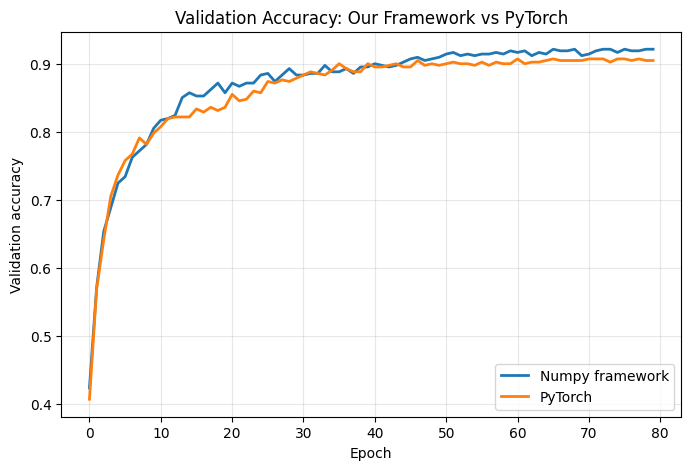

Our best validation accuracy: 0.9218
PyTorch best validation accuracy: 0.9076
Final validation accuracy difference: 0.0166
PyTorch test accuracy: 0.9007
PyTorch test macro-F1:  0.8968

Confusion matrix:
[[49  5  0  0  0  0  0]
 [ 3 41  0  0  0 12  2]
 [ 0  0 68  1  0  0  1]
 [ 0  0  1 58  1  0  0]
 [ 0  0  0  0 65  0  0]
 [ 0  9  0  0  0 46  3]
 [ 0  2  2  0  0  0 54]]


In [14]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import time
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

torch.manual_seed(RANDOM_STATE)

# TODO: Build the same architecture in nn.Sequential; same init scheme
torch_model = nn.Sequential(
    nn.Linear(n_features, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 7)
)
#   (nn.init.kaiming_normal_ on each Linear weight).
for layer in torch_model:
    if isinstance(layer, nn.Linear):
        nn.init.kaiming_normal_(
            layer.weight,
            mode="fan_in",
            nonlinearity="relu"
        )
        nn.init.zeros_(layer.bias)

print(torch_model)

# TODO: Train with torch.optim.Adam using the SAME lr, batch size, and epochs.

X_train_torch = torch.tensor(X_train, dtype=torch.float32)
y_train_torch = torch.tensor(y_train, dtype=torch.long)

X_val_torch = torch.tensor(X_val, dtype=torch.float32)
y_val_torch = torch.tensor(y_val, dtype=torch.long)

X_test_torch = torch.tensor(X_test, dtype=torch.float32)
y_test_torch = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_torch, y_train_torch)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

# Training the model

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    torch_model.parameters(),
    lr=0.001
)

torch_train_losses = []
torch_val_losses = []
torch_train_accs = []
torch_val_accs = []


torch_start_time = time.perf_counter()
for epoch in range(80):

    torch_model.train()

    epoch_loss = 0.0
    epoch_correct = 0
    epoch_samples = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        logits = torch_model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        batch_n = X_batch.shape[0]

        epoch_loss += loss.item() * batch_n
        epoch_correct += (logits.argmax(dim=1) == y_batch).sum().item()
        epoch_samples += batch_n

    train_loss = epoch_loss / epoch_samples
    train_acc = epoch_correct / epoch_samples

    # Validation
    torch_model.eval()

    with torch.no_grad():
        val_logits = torch_model(X_val_torch)
        val_loss = criterion(val_logits, y_val_torch).item()
        val_predictions = val_logits.argmax(dim=1)

        val_acc = (
            (val_predictions == y_val_torch)
            .float()
            .mean()
            .item()
        )

    torch_train_losses.append(train_loss)
    torch_train_accs.append(train_acc)
    torch_val_losses.append(val_loss)
    torch_val_accs.append(val_acc)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:3d}/80 | "
            f"Train loss: {train_loss:.4f} | "
            f"Train acc: {train_acc:.4f} | "
            f"Val loss: {val_loss:.4f} | "
            f"Val acc: {val_acc:.4f}"
        )
torch_time = time.perf_counter() - torch_start_time

# TODO: Time both training runs (time.perf_counter). Report the speed ratio.


start_time = time.perf_counter()

numpy_model, numpy_history = minibatch(
    obesity_model,
    Adam(lr=0.001),
    epochs=80,
    batch_size=32
)

numpy_time = time.perf_counter() - start_time

print(f"Our framework training time: {numpy_time:.4f} seconds")

speed_ratio = numpy_time / torch_time

print(f"Speed ratio (our framework / PyTorch): {speed_ratio:.2f}x")

if speed_ratio > 1:
    print(f"PyTorch was approximately {speed_ratio:.2f}x faster.")
else:
    print(f"Numpy framework was approximately {1/speed_ratio:.2f}x faster.")


# TODO: Overlay validation-accuracy curves: your framework vs PyTorch, same axes.
#   They will not be identical (different batch shuffles) but should track closely
#   and converge to similar accuracy (within ~1-2%).

plt.figure(figsize=(8, 5))

plt.plot(
    numpy_history["val_acc"],
    label="Numpy framework",
    linewidth=2
)

plt.plot(
    torch_val_accs,
    label="PyTorch",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Validation Accuracy: Our Framework vs PyTorch")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

print(
    f"Our best validation accuracy: "
    f"{np.max(numpy_history['val_acc']):.4f}"
)

print(
    f"PyTorch best validation accuracy: "
    f"{np.max(torch_val_accs):.4f}"
)

print(
    f"Final validation accuracy difference: "
    f"{abs(numpy_history['val_acc'][-1] - torch_val_accs[-1]):.4f}"
)



# TODO: Final test-set evaluation of the PyTorch model: accuracy, macro-F1,
#   confusion matrix (sklearn), and a comparison row against your best Lab 2
#   classical model.


torch_model.eval()

with torch.no_grad():
    test_logits = torch_model(X_test_torch)
    test_predictions = test_logits.argmax(dim=1).cpu().numpy()

y_test_np = y_test_torch.cpu().numpy()

torch_test_accuracy = accuracy_score(
    y_test_np,
    test_predictions
)

torch_test_f1 = f1_score(
    y_test_np,
    test_predictions,
    average="macro"
)

torch_cm = confusion_matrix(
    y_test_np,
    test_predictions
)

print(f"PyTorch test accuracy: {torch_test_accuracy:.4f}")
print(f"PyTorch test macro-F1:  {torch_test_f1:.4f}")

print("\nConfusion matrix:")
print(torch_cm)


**Student Reasoning — Parity**
*1. Do the two curves agree? If they diverge, list the sources of remaining randomness or
implementation difference you would investigate.*
ANSWER: Yes, they agree.The sources of remaining randomness might be due to random initialization or data shuffling.

*2. Where does PyTorch's speed advantage come from, given both use the same NumPy-level
math? Name at least two mechanisms.*

ANSWER: Pytorch uses optimized tensor operations and can reduce overhead. It also has the advantage of the optimized CPU libraries and hardware acceleration such as GPUs.


*3. After building all of this: what does `loss.backward()` actually do, mechanically? Answer
in terms of the layer API you implemented.*

ANSWER: It starts with the gradient of the loss and propagates it backward through the layers in reverse order. Each API layer uses its backward method to calculate the gradients of its inputs and parameters and passes them to the previous layer.



---
# Section 5 — Bonus Challenge: Batch Normalization *(optional, extra credit)*

Implement a `BatchNorm` layer for your framework — forward AND backward — and show it lets
you train the 6-layer *naively-initialized* network from Part 2.2 successfully.

- Forward (training mode): normalize each feature over the batch, then scale and shift with
  learnable `gamma`, `beta`. Maintain running statistics for inference mode.
- Backward: derive `dL/dx` carefully — the batch mean and variance both depend on every
  sample, so this is the hardest derivation in the lab. Include the derivation.
- Verify with your `numerical_gradient` checker before training with it!

In [ ]:
# class BatchNorm:
#     ...your implementation and gradient check...

---
# Section 6 — Reflection

*Answer in a few sentences each:*

1. **Abstraction:** Your `Layer` API, PyTorch's `nn.Module`, and the chain rule are one and
   the same idea. Explain how the chain rule shows up in the STRUCTURE of your code, not
   just in the formulas.

  ANSWER: The chain rule is essentially the architecture of my code. Each layer has a forward() method which computes its output and caches it for its derivative and a backward() method which goes through the layers in reverse order and passes the gradient from one layer into the previous layer. All this is as a result of the chain rule.

2. **Debugging deep learning:** Gradient checking caught bugs symptom-free training would
   have hidden. What OTHER silent failure modes did you meet this week (init, learning rate,
   ...) and what diagnostic would reveal each?

ANSWER: Gradient checking showed me that the model can appear to train normally even when gradients are wrong.
Another error was with my Momentum implementation. It initially failed to multiply the update by the velocity. Testing the optimizer on a simpler problem might reveal this issue.

3. **Judgment:** You will likely never write backprop by hand again. What, concretely, do
   you now understand about training that a student who only ever calls `.fit()` does not —
   and when will that matter in practice?

ANSWER: Implementing backpropagation manually has helped me to understand what happens behind Pytorch frameworks i have been using. I now understand exactly how the forward pass, backward pass and parameter update work using the chain rule as opposed to simply using fit().

>

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] All derivations included (Dense backward, Softmax+CE, He init argument; BatchNorm if
      attempted).
- [ ] Gradient check reported and passing (< 1e-5 max relative error).
- [ ] Optimizer race, initialization experiment, and parity plots visible in the notebook.
- [ ] Every **Student Reasoning** box filled in with full sentences.
- [ ] Notebook pushed to `lab-3-nn-framework` with incremental commits.
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.